# Week-1 Assignment

# **Gotta catch 'em all !**

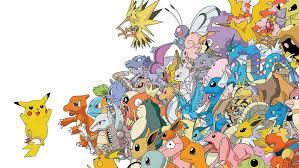

**Welcome to your first graded assignment! Hope that you are excited to implement and test everything you have learnt up until now. The dataset which you'll use includes information about Pokemons.**

**We have got an interesting set of questions for you to get a basic understanding of pandas and data visualization libraries. GOOD LUCK!**


***Let's get started with importing numpy, pandas, seaborn and matplotlib!***

Note - matplotlib should be imported with the command :

 `import matplotlib.pyplot as plt`

### 1) Start by importing all important libraries
For eg, "import numpy as np"

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



### 2) Read the csv file and assign it to a variable .

In [2]:
file = pd.read_csv(r"D:\DOWNLOADS\W1_Pokemon.csv")

### 3) Display shape of dataframe
Expected Output - (800, 13)

In [3]:
print(file.shape)


(800, 13)


### 4) Print all columns of dataframe
Return an array containing names of all the columns.

In [4]:
print(file.columns)#your code here


Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')


### 5) Remove the column '#' and update the dataframe.

In [5]:
file =file.drop("#", axis=1)


In [6]:
print(file.columns)

Index(['Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')


### 6) Set the 'Name' column as the index of dataframe

In [7]:
file = file.set_index("Name" , drop=False)

In [8]:
print(file.index)

Index(['Bulbasaur', 'Ivysaur', 'Venusaur', 'VenusaurMega Venusaur',
       'Charmander', 'Charmeleon', 'Charizard', 'CharizardMega Charizard X',
       'CharizardMega Charizard Y', 'Squirtle',
       ...
       'Noibat', 'Noivern', 'Xerneas', 'Yveltal', 'Zygarde50% Forme',
       'Diancie', 'DiancieMega Diancie', 'HoopaHoopa Confined',
       'HoopaHoopa Unbound', 'Volcanion'],
      dtype='object', name='Name', length=800)


In [9]:
print(file.columns)

Index(['Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')


###  7) Print a list of all the unique Type-1 powers

In [10]:
#your code here
print(file["Type 1"].unique())

['Grass' 'Fire' 'Water' 'Bug' 'Normal' 'Poison' 'Electric' 'Ground'
 'Fairy' 'Fighting' 'Psychic' 'Rock' 'Ghost' 'Ice' 'Dragon' 'Dark' 'Steel'
 'Flying']


### 8) Create a column which contains the Type 1 and Type 2 abilities of pokemons, seperated with a '+'' sign. Also, display the no. of pokemons that have type-1 power as 'Psychic' and type 2 power as 'Flying' using this new column.

In [11]:
#your code here
file["type1+2"]= file["Type 1"] + "+" + file["Type 2"]

In [12]:
count = (file["type1+2"] == "Psychic+Flying").sum()
print("Number of Pokémon:", count)

Number of Pokémon: 6


## GRADED Questions (To be answered in the quiz)
### Try to retrieve some information from the data and answer the questions below . BEST OF LUCK !!

### 1. How many pokemons have 'Mega' in their name?

In [14]:
#your code here
count = file["Name"].str.contains("Mega").sum()
print(count)

49


### 2. What is the standard deviation of Sp. Def. in the dataset ?

In [29]:

print("Standard Deviation of Sp. Def:", file["Sp. Def"].std())

Standard Deviation of Sp. Def: 27.82891579711745


### 3. What percentage (upto 3 decimal places) of pokemons are legendary ?

In [41]:
percentage = ((file["Legendary"]).sum())/ len(file)*100
print(percentage)

8.125


### 4. Name the pokemon(s) with Maximum Defense.

In [51]:
max_def_pok = file[file["Defense"]==file["Defense"].max()]
print(max_def_pok.Name)

Name
SteelixMega Steelix    SteelixMega Steelix
Shuckle                            Shuckle
AggronMega Aggron        AggronMega Aggron
Name: Name, dtype: object


### 5. Which poison pokemon has the strongest attack ?

In [55]:
poison_p = file[(file["Type 1"] == "Poison") | (file["Type 2"] == "Poison")]
max_poison_attack = poison_p["Attack"].max()
strongest_poison = poison_p[poison_p["Attack"] == max_poison_attack]
print(strongest_poison.Name)

Name
BeedrillMega Beedrill    BeedrillMega Beedrill
Name: Name, dtype: object


### 6. Using seaborn make different types of plots, observe the trend and answer the questions given in the form.

In [81]:
#your code here
import seaborn as sns

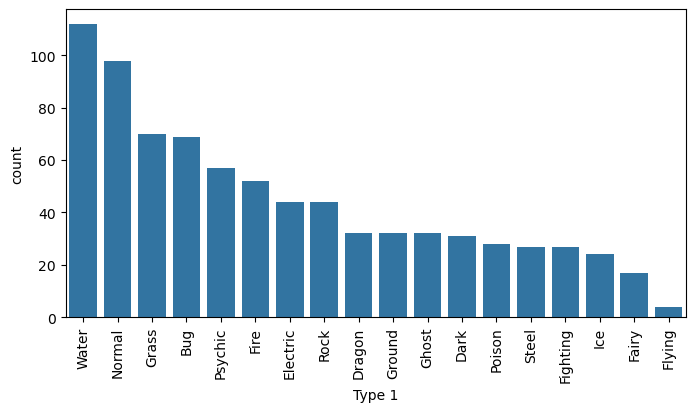

In [87]:
plt.figure(figsize=(8,4))
sns.countplot(data=file, x='Type 1', order=file['Type 1'].value_counts().index)
plt.xticks(rotation=90)
plt.show()

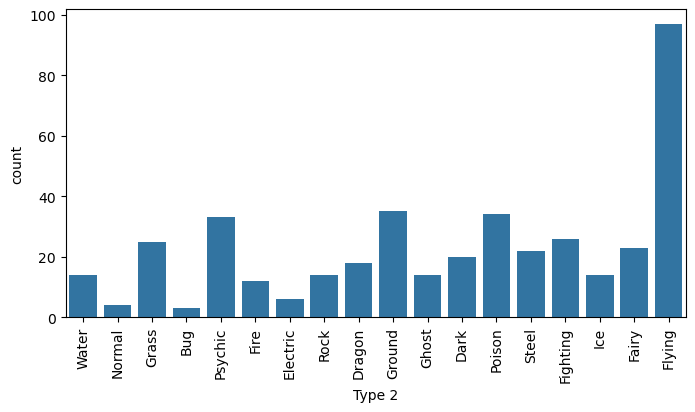

In [88]:
plt.figure(figsize=(8,4))
sns.countplot(data=file, x='Type 2', order=file['Type 1'].value_counts().index)
plt.xticks(rotation=90)
plt.show()


### 7. Which is the second fastest non-legendary 'Ghost' type pokemon from 4th generation ?

In [56]:
ghost_gen4_nonl = file[((file["Type 1"] == "Ghost") | (file["Type 2"] == "Ghost")) &(file["Generation"] == 4) &(file["Legendary"] == 0)]
ghost_sort = ghost_gen4_nonl.sort_values(by="Speed", ascending=False)
print(ghost_sort.iloc[1])

Name          Mismagius
Type 1            Ghost
Type 2              NaN
Total               495
HP                   60
Attack               60
Defense              60
Sp. Atk             105
Sp. Def             105
Speed               105
Generation            4
Legendary         False
type1+2             NaN
Name: Mismagius, dtype: object


### 8. How many non-legendary pokemons have stronger defence but weaker attack than Charizard?

In [63]:

charizard = file[file["Name"] == "Charizard"].iloc[0]

char_attack = charizard["Attack"]
char_defense = charizard["Defense"]


result = file[ (file["Legendary"] == 0) &(file["Defense"] > char_defense) &(file["Attack"] < char_attack)]
print(len(result))

116
